Target distribution:
 WillDonate
1    5000
0    5000
Name: count, dtype: int64 

MODEL RESULTS::
Accuracy: 92.55%
AUC Score: 0.988

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      1000
           1       0.93      0.92      0.93      1000

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000


Average AUC (5-Fold CV): 0.988


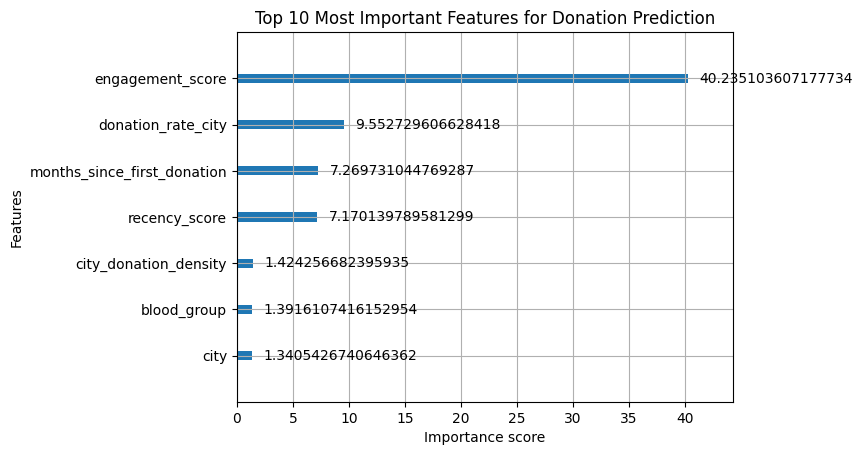

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import xgboost as xgb
import matplotlib.pyplot as plt


df = pd.read_csv("C:/Users/Parthiv/Downloads/blood_donor_dataset.csv")
df["created_at"] = pd.to_numeric(df["created_at"], errors="coerce")



df["donor_activity_score"] = (
    0.6 * df["number_of_donation"] +
    0.3 * df["pints_donated"] -
    0.2 * df["months_since_first_donation"] +
    np.random.normal(0, 0.5, len(df))
)
median_score = df["donor_activity_score"].median()
df["WillDonate"] = (df["donor_activity_score"] > median_score).astype(int)

print("Target distribution:\n", df["WillDonate"].value_counts(), "\n")


# Feature Engineering (non-leaky)


# Derived behavior features 
df["recency_score"] = 1 / (df["months_since_first_donation"] + 1)
df["city_donation_density"] = df.groupby("city")["number_of_donation"].transform("mean")
df["donation_rate_city"] = df["number_of_donation"] / (df["city_donation_density"] + 1)
df["engagement_score"] = (df["recency_score"] + df["donation_rate_city"]) / 2

# Drop irrelevant columns
drop_cols = [
    "donor_id", "name", "email", "password",
    "contact_number", "availability", "donor_activity_score",
    "number_of_donation", "pints_donated"
]
df = df.drop(columns=drop_cols)


#  Encode Categorical Columns

cat_cols = ["city", "blood_group"]
encoder = LabelEncoder()
for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])


#  Split Features & Target

X = df.drop("WillDonate", axis=1)
y = df["WillDonate"]


#  Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


#  XGBoost Tuned Model

model = xgb.XGBClassifier(
    learning_rate=0.03,
    n_estimators=800,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    gamma=0.2,
    min_child_weight=4,
    objective="binary:logistic",
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)


#  Evaluation

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("MODEL RESULTS::")
print(f"Accuracy: {acc*100:.2f}%")
print(f"AUC Score: {auc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# Cross-Validation (Robust Accuracy)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
print(f"\nAverage AUC (5-Fold CV): {cv_scores.mean():.3f}")


# Feature Importance Plot

xgb.plot_importance(model, importance_type="gain", max_num_features=10)
plt.title("Top 10 Most Important Features for Donation Prediction")
plt.show()


In [2]:
import joblib
joblib.dump(model, "donor_predictor.pkl")
print("Model saved successfully as donor_predictor.pkl")


Model saved successfully as donor_predictor.pkl


In [3]:
# --- Compute confusion matrix ---
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_val, y_pred)
labels = ["Not Donate (0)", "Will Donate (1)"]

# --- Plot confusion matrix ---
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix — Blood Donation Prediction", fontsize=13)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

NameError: name 'y_val' is not defined